In [1]:
#pkgs for EDA
import pandas as pd
import numpy as np

#pkgs for visulization
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
#data prep
df = pd.read_csv("../dataset/ai4i2020.csv")

In [4]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
#checking for null value
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [7]:
#descriptive
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


array([[<Axes: title={'center': 'UDI'}>,
        <Axes: title={'center': 'Air temperature [K]'}>,
        <Axes: title={'center': 'Process temperature [K]'}>],
       [<Axes: title={'center': 'Rotational speed [rpm]'}>,
        <Axes: title={'center': 'Torque [Nm]'}>,
        <Axes: title={'center': 'Tool wear [min]'}>],
       [<Axes: title={'center': 'Machine failure'}>,
        <Axes: title={'center': 'TWF'}>, <Axes: title={'center': 'HDF'}>],
       [<Axes: title={'center': 'PWF'}>, <Axes: title={'center': 'OSF'}>,
        <Axes: title={'center': 'RNF'}>]], dtype=object)

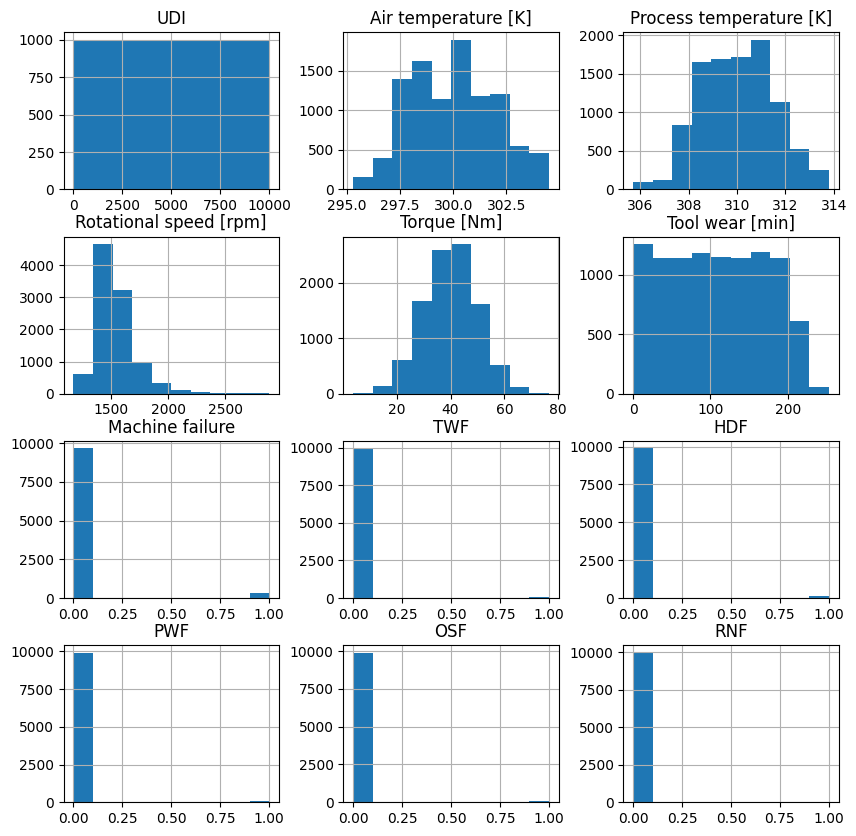

In [8]:
df.hist(figsize=(10,10))

In [10]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

<Axes: xlabel='Machine failure', ylabel='count'>

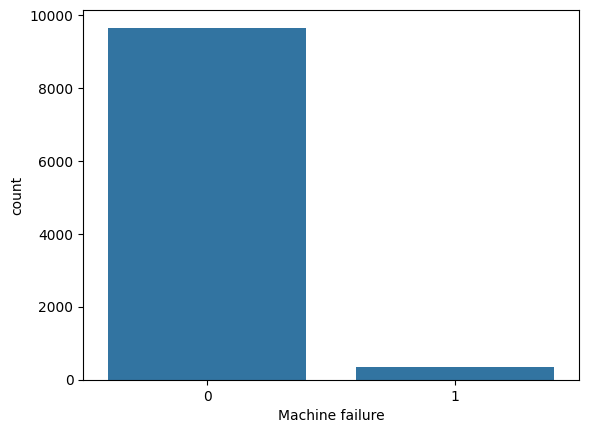

In [11]:
sns.countplot(x= 'Machine failure', data=df)

In [13]:
#classify failures
classify_failes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

def classify_failure_types(row):
    for col in classify_failes:
        if row[col]==1:
            return col
    return "No failure"

In [14]:
df['Failure type'] = df.apply(classify_failure_types, axis=1)

In [16]:
df['Failure type']

0       No failure
1       No failure
2       No failure
3       No failure
4       No failure
           ...    
9995    No failure
9996    No failure
9997    No failure
9998    No failure
9999    No failure
Name: Failure type, Length: 10000, dtype: str

<Axes: xlabel='Failure type', ylabel='count'>

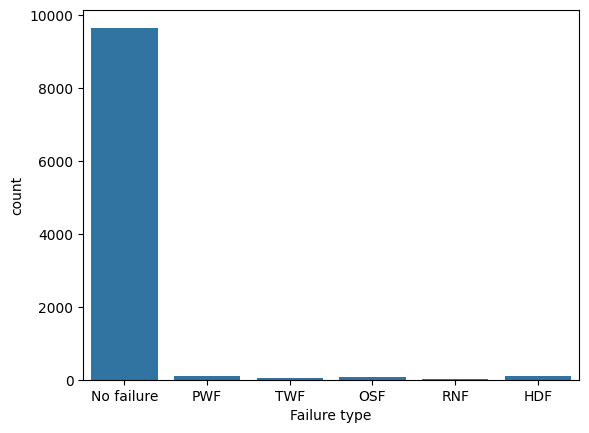

In [17]:
sns.countplot(data=df, x='Failure type')

<Axes: xlabel='Type', ylabel='count'>

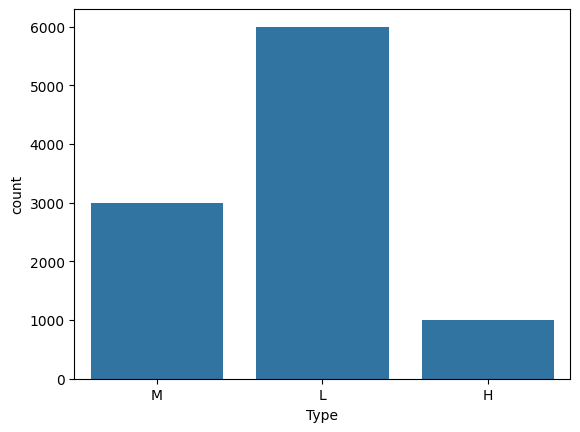

In [18]:
sns.countplot(x='Type', data=df)

In [19]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure type'],
      dtype='str')

<Axes: xlabel='Air temperature [K]', ylabel='Process temperature [K]'>

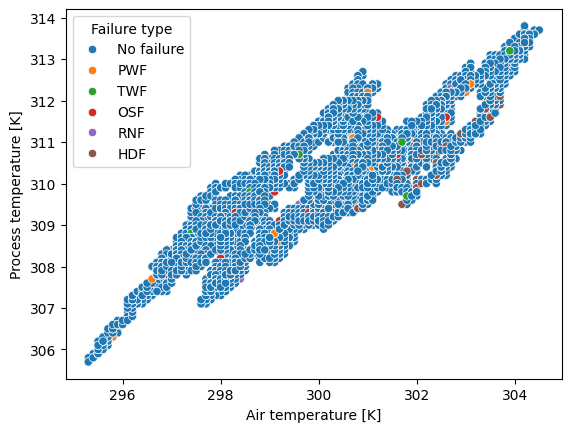

In [21]:
sns.scatterplot(x='Air temperature [K]', y= 'Process temperature [K]', hue='Failure type', data=df)

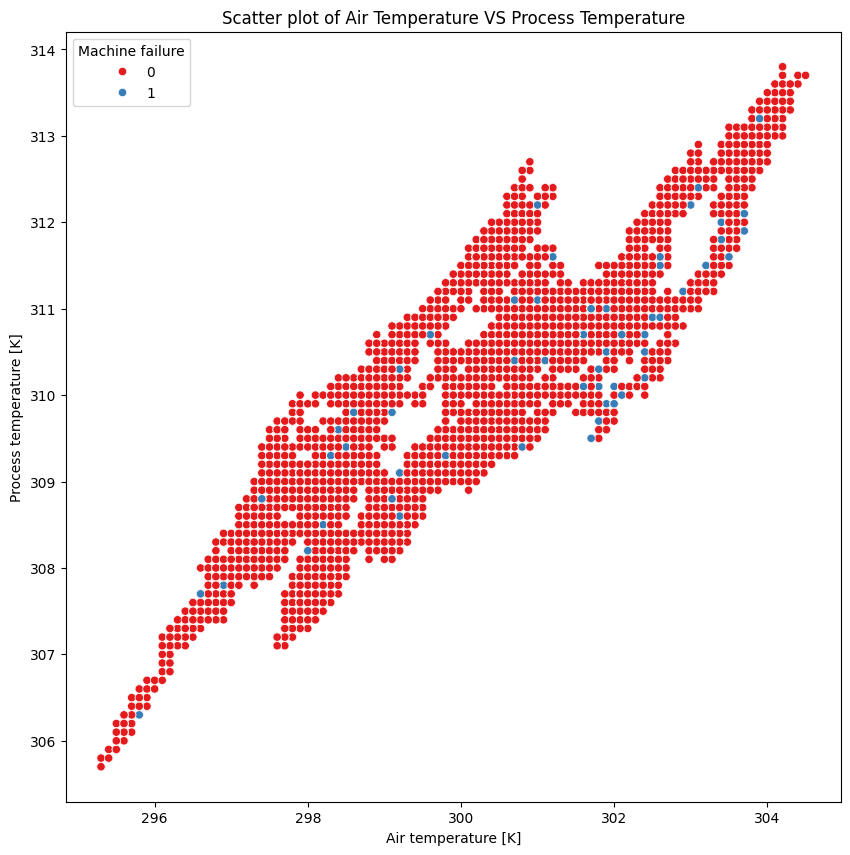

In [23]:
plt.figure(figsize=(10,10))

sns.scatterplot(
    x='Air temperature [K]',
    y= 'Process temperature [K]',
    hue= 'Machine failure',
    data=df,
    palette='Set1',
)
plt.title('Scatter plot of Air Temperature VS Process Temperature')
plt.show()

In [24]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure type'],
      dtype='str')

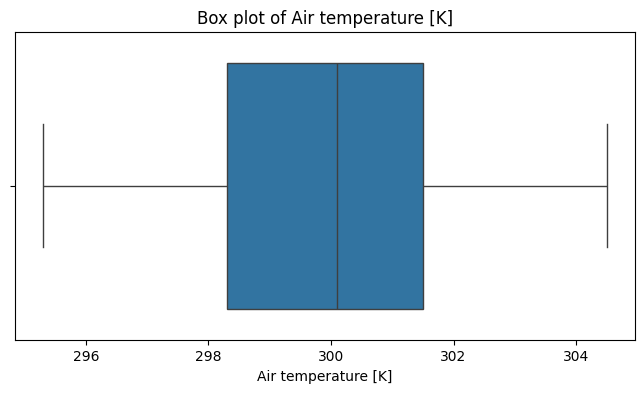

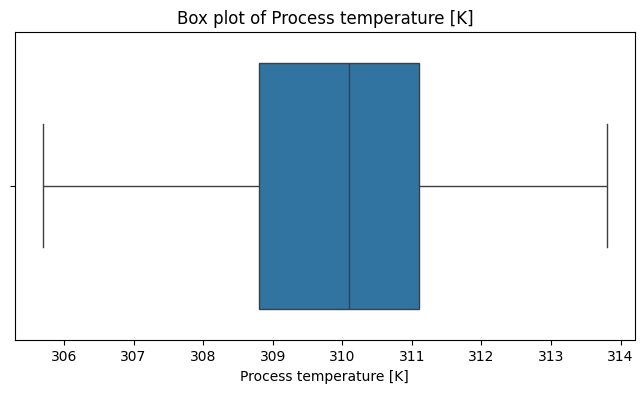

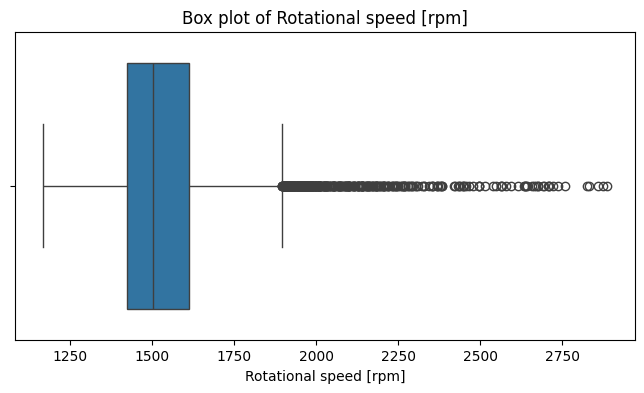

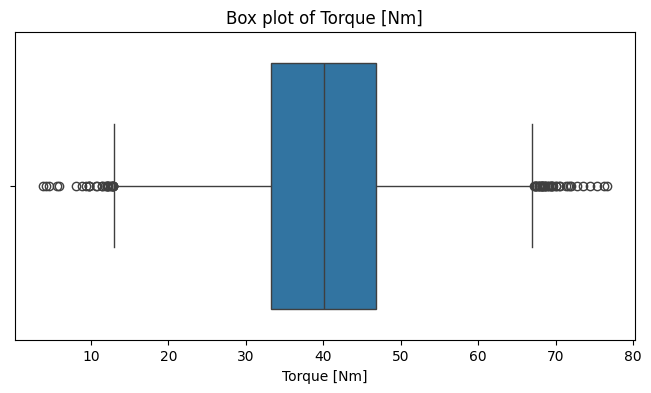

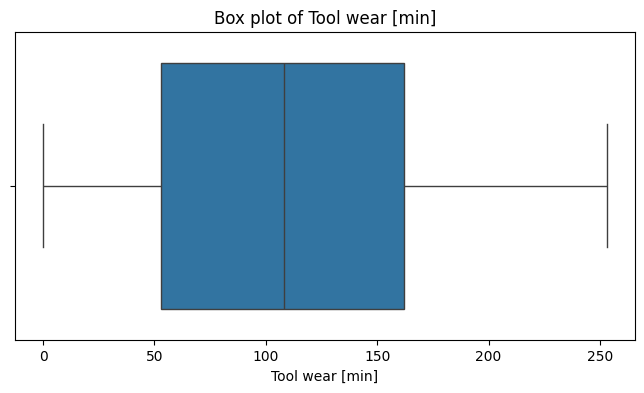

In [25]:
# Outliers detection: Boxplot

sensor_cols = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for col in sensor_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f'Box plot of {col}')
    plt.show()

### Narative
+ Torque and Rotation speed had more outliers or have thier value out of range than normal

### Feature engineering and ML

In [26]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Failure type'],
      dtype='str')

In [28]:
df['Type'] = df['Type'].map({'L':0, 'M':1, 'H':2})

In [29]:
feature_cols = ['Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]']

Xfeatures= df[feature_cols]
ylabel= df['Machine failure']